# Does the micelle bias follow the working point, or the number of crossings?

Across six nuclides the efficiency bias from omitting `micCorr` falls as the
efficiency rises. Restricted to the four dispersion-dominated nuclides it is
perfectly monotonic in efficiency — and **equally perfectly monotonic in the
number of droplet crossings**, because those two are themselves collinear:

| | ³H | ⁶³Ni | ¹⁴C | ⁹⁹Tc |
|---|---|---|---|---|
| bias / % | 0.62 | 0.35 | 0.12 | 0.03 |
| efficiency | 0.700 | 0.862 | 0.964 | 0.975 |
| crossings | ~14 | ~138 | ~1091 | ~4033 |

Two explanations fit that ordering exactly, and a cross-nuclide comparison
cannot separate them:

* **Working point.** The same photon-budget error displaces a steep efficiency
  curve more than a saturated one. This makes the bias a property of the
  *measurement*.
* **Crossing number.** The relative dispersion of the aqueous path length falls
  roughly as $1/\sqrt{N_{\text{cross}}}$, so a track that crosses thousands of
  droplets has a nearly deterministic path and little dispersion left to bias
  anything. This makes the bias a property of the *radionuclide*.

**This notebook separates them.** One radionuclide — ³H — is fitted at several
different measured TDCR ratios. The spectrum is identical at every point, so
the range, the droplet crossings and the retention distribution are identical
too. **Only the working point moves.**

* If the bias tracks the efficiency here, the working-point mechanism is real
  and the crossing-number explanation cannot account for it.
* If the bias is flat, the working point does nothing and the cross-nuclide
  ordering was the crossing number all along.

Either outcome settles the question. The prediction of the crossing-number
explanation alone is a flat line; the prediction of the working-point
explanation is the same fall seen across nuclides.


In [1]:
import importlib, io, contextlib, time, warnings
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from importlib.metadata import version

import tdcrpy.TDCR_model_lib as tl
import tdcrpy.TDCRPy as tm

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})
print(f'TDCRPy {version("TDCRPy")}')

TDCRPy 2.20.28


In [2]:
# ---- conditions: identical to micelleCheck, so the results are comparable --
RAD      = 'H-3'
KB       = 1e-5
V        = 10
N        = 500000
FAQ      = 0.10
DIAM     = 4
SIGMA    = 0.0
COCKTAIL = 'Ultima Gold'

# Measured ratios to fit. 0.668 is the value used in micelleCheck; the others
# are the same counter run better or worse. They span the efficiency curve
# from well below the usual working point to near saturation.
TD_SCAN = [0.40, 0.50, 0.60, 0.668, 0.75, 0.82, 0.88]

# Wide enough to reach the top of the scan. H-3's modelled TDCR rises
# monotonically to L = 60 (it does not turn over as Fe-55 and Cr-51 do), so a
# wide grid is safe for this nuclide.
L_GRID = np.logspace(np.log10(0.5), np.log10(60.0), 45)

NOMINAL = dict(fAq=tl.fAq, micCorr=tl.micCorr,
               diam=tl.diam_micelle, sigma=tl.sigma_micelle)


def set_state(micCorr):
    global tl, tm
    with contextlib.redirect_stdout(io.StringIO()):
        tl.modifyLScocktail(COCKTAIL, FAQ, 'Water', 0.0)
    tl.modifyDiam_micelle(DIAM)
    tl.modifySigma_micelle(SIGMA)
    tl.modifyMicCorr(bool(micCorr))
    tl = importlib.reload(tl)
    tm = importlib.reload(tm)


set_state(False)
print(f'{RAD} in {COCKTAIL} + {FAQ:.0%} water, {DIAM} nm droplets, '
      f'sigma = {SIGMA:g}')
print(f'kB = {KB} cm/keV, V = {V} mL, N = {N}')
print(f'fitting {len(TD_SCAN)} measured ratios: {TD_SCAN}')

H-3 in Ultima Gold + 10% water, 4 nm droplets, sigma = 0
kB = 1e-05 cm/keV, V = 10 mL, N = 500000
fitting 7 measured ratios: [0.4, 0.5, 0.6, 0.668, 0.75, 0.82, 0.88]


## 1. One simulation per arm, many working points

The decay histories do not depend on the ratio being fitted — only on the
nuclide and on whether the correction is active. So each arm is simulated
**once** and then replayed across a grid of `L`; every working point in the
scan is read off that one curve.

That is what makes this test cheap: seven fits for the price of two
simulations. It is also what makes it clean, because every point in the scan
uses the *same* decays.


In [3]:
import json, os

SCAN_CACHE = 'micelleWorkingPoint_scan.json'


def run_scan(n, label=''):
    """Fit every working point in TD_SCAN at N = n, for both arms.

    One simulation per arm, replayed across L_GRID; every point in the scan is
    read off that one curve, so the whole scan costs two simulations.
    """
    out = {}
    for mic in (False, True):
        t0 = time.time()
        set_state(mic)
        tm.TDCRPy(2.0, RAD, '1', n, KB, V, record=True)     # one simulation
        tdcr, effd = [], []
        for Lg in L_GRID:
            o = tm.TDCRPy(Lg, RAD, '1', n, KB, V, readRecHist=True)
            tdcr.append(o[4] / o[2] if o[2] > 0 else np.nan)
            effd.append(o[2])
        tdcr = np.array(tdcr)
        order = np.argsort(tdcr)
        pts = {}
        for td_target in TD_SCAN:
            if not (np.nanmin(tdcr) < td_target < np.nanmax(tdcr)):
                continue
            L_fit = float(np.interp(td_target, tdcr[order], L_GRID[order]))
            o = tm.TDCRPy(L_fit, RAD, '1', n, KB, V, readRecHist=True)
            pts[td_target] = dict(L=L_fit, D=o[2], uD=o[3])
        out[mic] = pts
        print(f'  {label}micCorr={str(mic):5s}: {len(pts)} points   '
              f'[{time.time()-t0:.0f} s]', flush=True)
    return out


def rows_from(scan_out):
    """(efficiency, bias, uncertainty) at each working point."""
    tds = [t for t in TD_SCAN if t in scan_out[False] and t in scan_out[True]]
    e, b, u = [], [], []
    for t in tds:
        a, c = scan_out[False][t], scan_out[True][t]
        e.append(c['D'])
        b.append(100 * (a['D'] - c['D']) / c['D'])
        u.append(100 * np.hypot(a['uD'], c['uD']) / c['D'])
    return np.array(e), np.array(b), np.array(u), tds


KEY = dict(RAD=RAD, N=N, FAQ=FAQ, DIAM=DIAM, SIGMA=SIGMA, KB=KB, V=V,
           TD_SCAN=list(TD_SCAN), tdcrpy=version('TDCRPy'))
_hit = None
if os.path.exists(SCAN_CACHE):
    _blob = json.load(open(SCAN_CACHE, encoding='utf-8'))
    if _blob.get('key') == KEY:
        _hit = _blob['rows']
        print(f'cache {SCAN_CACHE}: {len(_hit)} points match these conditions')
    else:
        print(f'cache {SCAN_CACHE} was made under other conditions -- ignored')

if _hit is not None:
    eff = np.array([r['D_on'] for r in _hit])
    bias = np.array([r['bias'] for r in _hit])
    ubias = np.array([r['ubias'] for r in _hit])
    TD_OK = [r['TD'] for r in _hit]
    rows = _hit
else:
    _scan = run_scan(N)
    eff, bias, ubias, TD_OK = rows_from(_scan)
    rows = [dict(TD=t, L_off=_scan[False][t]['L'], L_on=_scan[True][t]['L'],
                 D_off=_scan[False][t]['D'], D_on=_scan[True][t]['D'],
                 bias=float(b), ubias=float(u))
            for t, b, u in zip(TD_OK, bias, ubias)]
    json.dump({'key': KEY, 'rows': rows},
              open(SCAN_CACHE, 'w', encoding='utf-8'), indent=1)

print(f'\n{"TD":>6s} {"L uncorr":>9s} {"L corr":>8s} | {"eff_D uncorr":>13s} '
      f'{"eff_D corr":>11s} {"bias %":>8s} {"+-":>6s} {"z":>6s}')
print('-' * 76)
for r in rows:
    print(f'{r["TD"]:6.3f} {r["L_off"]:9.4f} {r["L_on"]:8.4f} | '
          f'{r["D_off"]:13.5f} {r["D_on"]:11.5f} {r["bias"]:8.3f} '
          f'{r["ubias"]:6.3f} {r["bias"]/r["ubias"]:6.2f}')

cache micelleWorkingPoint_scan.json: 7 points match these conditions

    TD  L uncorr   L corr |  eff_D uncorr  eff_D corr   bias %     +-      z
----------------------------------------------------------------------------
 0.400    2.4454   2.7174 |       0.43912     0.43727    0.424  0.147   2.88
 0.500    3.4178   3.7935 |       0.54416     0.54135    0.520  0.128   4.06
 0.600    4.7821   5.2984 |       0.63936     0.63531    0.637  0.111   5.76
 0.668    6.1177   6.7651 |       0.69984     0.69471    0.738  0.099   7.43
 0.750    8.6728   9.5340 |       0.77117     0.76392    0.950  0.086  11.10
 0.820   12.7058  13.8574 |       0.83154     0.82189    1.173  0.073  16.06
 0.880   20.1315  21.5233 |       0.88442     0.87090    1.553  0.061  25.41


## 2. The test

The crossing number is identical at every point above — same nuclide, same
spectrum, same transport. So any dependence of the bias on the efficiency here
is the working point and nothing else.


In [4]:
# The cross-nuclide comparison this test exists to explain, read straight from
# micelleCheck's fitted results rather than copied by hand. A literal here
# would go stale the moment those are recomputed, and nothing would say so.
import json

with open('micelleCheck_fits.json', encoding='utf-8') as _fh:
    _fits = json.load(_fh)
print(f'cross-nuclide values from micelleCheck_fits.json '
      f'(TDCRPy {_fits["key"].get("tdcrpy", "unrecorded")}, '
      f'N = {_fits["key"]["N"]})')
CROSS = {}
for _rad in ('H-3', 'Fe-55', 'Cr-51', 'Ni-63', 'C-14', 'Tc-99'):
    _u, _c = _fits['fits'][f'{_rad}|False'], _fits['fits'][f'{_rad}|True']
    CROSS[_rad] = (_c['D'], 100 * (_u['D'] - _c['D']) / _c['D'])
for _rad, (_e, _b) in CROSS.items():
    print(f'  {_rad:7s} eff_D = {_e:.5f}   bias = {_b:.3f} %')

rho, p_rho = spearmanr(eff, bias)

# The points share one pair of simulations -- the same recorded histories are
# replayed at every L -- so they are strongly correlated. A common fluctuation
# shifts the whole scan up or down and cannot create a trend, which is what
# makes the SHAPE well determined. But it also means the per-point error bars
# are largely common-mode, so a chi2 that assumes independence would be
# meaningless. The slope below is therefore quoted without one.
slope, intercept = np.polyfit(eff, bias, 1)
span_obs = bias.max() - bias.min()

# What the working-point explanation predicts over this same efficiency range,
# calibrated on the cross-nuclide data it was invented to explain.
ce = np.array([v[0] for v in CROSS.values()])
cb = np.array([v[1] for v in CROSS.values()])
o = np.argsort(ce)
pred_lo = float(np.interp(eff.min(), ce[o], cb[o]))
pred_hi = float(np.interp(eff.max(), ce[o], cb[o]))
span_pred = abs(pred_lo - pred_hi)

print(f'working points fitted : {len(eff)}')
print(f'efficiency range      : {eff.min():.3f} to {eff.max():.3f}')
print(f'bias range            : {bias.min():.3f} % to {bias.max():.3f} %')
print(f'typical uncertainty   : +-{np.mean(ubias):.3f} % per point '
      f'(largely common-mode)')
print(f'\nSpearman rho(bias, efficiency) = {rho:+.3f}   (ordering only;')
print('  its p-value assumes independent points and does not apply here)')
print(f'least-squares slope   : {slope:+.3f} % per unit efficiency')

print(f'\nObserved change in bias across the scan : {span_obs:.3f} %')
print(f'Working-point prediction over the same   : {span_pred:.3f} %')
print(f'  (cross-nuclide bias is {pred_lo:.3f} % at eff = {eff.min():.3f} '
      f'and {pred_hi:.3f} % at eff = {eff.max():.3f})')
ratio = span_obs / span_pred if span_pred > 0 else np.nan
print(f'  observed / predicted = {ratio:.2f}')

i_lo, i_hi = int(np.argmin(eff)), int(np.argmax(eff))
u_span = float(np.hypot(ubias[i_lo], ubias[i_hi]))   # conservative: correlated
falls = bias[i_hi] < bias[i_lo]
resolved = span_obs > 2 * u_span

print(f'\nchange across the scan : {span_obs:.3f} % +- {u_span:.3f} % '
      f'(conservative)')
print(f'  resolved at 2 sigma  : {"yes" if resolved else "no"}')
print(f'  direction            : bias {"falls" if falls else "rises"} '
      f'with efficiency')

print('\n' + '=' * 72)
if not resolved:
    print('WORKING POINT NOT SUPPORTED. Across an efficiency range where the')
    print(f'cross-nuclide data would require a change of {span_pred:.2f} %, the')
    print(f'bias changes by {span_obs:.3f} +- {u_span:.3f} % at fixed crossing')
    print('number -- consistent with no dependence at all. The cross-nuclide')
    print('ordering is therefore not a working-point effect, and the crossing')
    print("number is the surviving explanation. Section 3.4's claim retires.")
elif falls:
    if ratio > 0.5:
        print('WORKING POINT CONFIRMED. The bias falls with rising efficiency')
        print('at fixed crossing number, by an amount comparable to the')
        print('cross-nuclide fall. The working point is a genuine mechanism and')
        print('the cross-nuclide ordering need not be the crossing number.')
    else:
        print('WORKING POINT REAL BUT INSUFFICIENT. The bias does fall with')
        print('efficiency at fixed crossing number, but by much less than the')
        print('cross-nuclide ordering requires. Both mechanisms are present,')
        print('and the crossing number carries most of that ordering.')
else:
    print('UNEXPECTED. The bias RISES with efficiency at fixed crossing')
    print('number. Neither candidate explanation predicts this, and the')
    print('cross-nuclide ordering cannot be a working-point effect as stated.')
print('=' * 72)
print('\nNote: the scan points share one pair of simulations, so a common')
print('fluctuation moves all of them together and cannot fake a trend. The')
print('error bars shown are per-point and therefore conservative for the')
print('shape, which is what is being tested here.')

cross-nuclide values from micelleCheck_fits.json (TDCRPy 2.20.28, N = 500000)
  H-3     eff_D = 0.69552   bias = 0.681 %
  Fe-55   eff_D = 0.78458   bias = 0.281 %
  Cr-51   eff_D = 0.72468   bias = 0.614 %
  Ni-63   eff_D = 0.85953   bias = 0.271 %
  C-14    eff_D = 0.96281   bias = 0.089 %
  Tc-99   eff_D = 0.97469   bias = 0.032 %
working points fitted : 7
efficiency range      : 0.437 to 0.871
bias range            : 0.424 % to 1.553 %
typical uncertainty   : +-0.101 % per point (largely common-mode)

Spearman rho(bias, efficiency) = +1.000   (ordering only;
  its p-value assumes independent points and does not apply here)
least-squares slope   : +2.400 % per unit efficiency

Observed change in bias across the scan : 1.129 %
Working-point prediction over the same   : 0.430 %
  (cross-nuclide bias is 0.681 % at eff = 0.437 and 0.251 % at eff = 0.871)
  observed / predicted = 2.63

change across the scan : 1.129 % +- 0.159 % (conservative)
  resolved at 2 sigma  : yes
  direction    

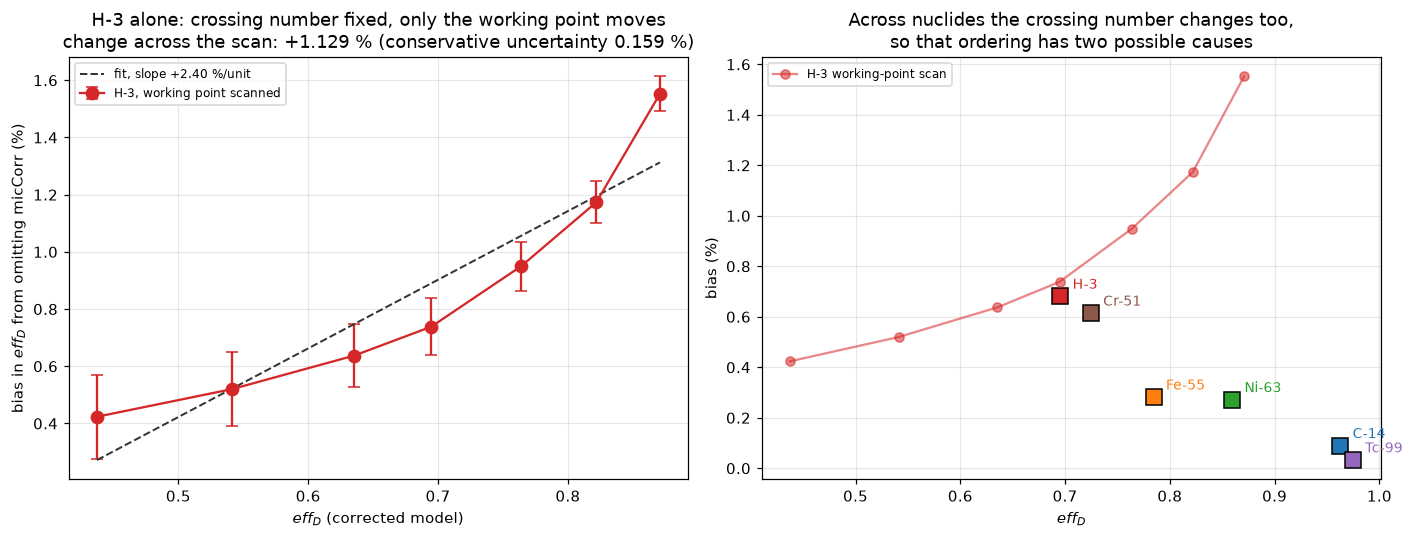

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.errorbar(eff, bias, yerr=ubias, fmt='o-', ms=8, capsize=4, color='#d62728',
            label=f'{RAD}, working point scanned')
xs = np.linspace(eff.min(), eff.max(), 50)
ax.plot(xs, slope * xs + intercept, '--', color='#333333', lw=1.3,
        label=f'fit, slope {slope:+.2f} %/unit')
ax.set_xlabel('$eff_D$ (corrected model)')
ax.set_ylabel('bias in $eff_D$ from omitting micCorr (%)')
ax.set_title(f'{RAD} alone: crossing number fixed, only the working '
             f'point moves\n'
             f'change across the scan: {span_obs:+.3f} % '
             f'(conservative uncertainty {u_span:.3f} %)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# the cross-nuclide picture, for contrast
ax = axes[1]
COL = {'H-3': '#d62728', 'Fe-55': '#ff7f0e', 'Cr-51': '#8c564b',
       'Ni-63': '#2ca02c', 'C-14': '#1f77b4', 'Tc-99': '#9467bd'}
for rad, (e, b) in CROSS.items():
    ax.plot(e, b, 's', ms=11, color=COL[rad], markeredgecolor='k')
    ax.annotate(rad, (e, b), textcoords='offset points', xytext=(8, 5),
                fontsize=9, color=COL[rad])
ax.plot(eff, bias, 'o-', ms=6, color='#d62728', alpha=0.55,
        label=f'{RAD} working-point scan')
ax.set_xlabel('$eff_D$'); ax.set_ylabel('bias (%)')
ax.set_title('Across nuclides the crossing number changes too,\n'
             'so that ordering has two possible causes')
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('micelle_workingpoint.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. How well is the slope determined?

The scan above is one realisation. Its per-point error bars are largely
common-mode, which is good for the shape but says nothing directly about the
uncertainty of the slope.

So the whole scan is repeated from scratch, at lower statistics to keep it
cheap. Each replicate is an independent pair of simulations — a different
random stream — so the spread of the fitted slopes is a direct, empirical
uncertainty on it, with no assumption about how the points within one scan are
correlated.


In [6]:
N_REP, N_REPLICATES = 100000, 3

slopes = [float(np.polyfit(eff, bias, 1)[0])]
labels = [f'main scan, N = {N}']
print(f'main scan     slope = {slopes[0]:+.3f} %/unit   (N = {N})')

for rep in range(N_REPLICATES):
    sc = run_scan(N_REP, label=f'replicate {rep+1}: ')
    e_r, b_r, u_r, _ = rows_from(sc)
    m = float(np.polyfit(e_r, b_r, 1)[0])
    slopes.append(m)
    labels.append(f'replicate {rep+1}, N = {N_REP}')
    print(f'replicate {rep+1}   slope = {m:+.3f} %/unit   '
          f'(N = {N_REP}, {len(e_r)} points)', flush=True)

rep_slopes = np.array(slopes[1:])
print(f'\nreplicates: mean {rep_slopes.mean():+.3f}, '
      f'sd {rep_slopes.std(ddof=1):.3f} %/unit over {len(rep_slopes)} runs')
print(f'main scan at N = {N}: {slopes[0]:+.3f} %/unit')
print(f'  the replicates are at N = {N_REP}, so their scatter is '
      f'{np.sqrt(N/N_REP):.1f}x')
print(f'  larger than the main scan would show; scaled, sd ~ '
      f'{rep_slopes.std(ddof=1)/np.sqrt(N/N_REP):.3f} %/unit')
print(f'\nslope / its sd = {abs(slopes[0]) / rep_slopes.std(ddof=1):.1f} '
      f'(using the unscaled, conservative sd)')
print('\nA sign reversal needs the slope to be wrong by more than its own')
print('size. Compare that ratio with 1.')

main scan     slope = +2.400 %/unit   (N = 500000)


  replicate 1: micCorr=False: 7 points   [361 s]


  replicate 1: micCorr=True : 7 points   [353 s]


replicate 1   slope = +2.519 %/unit   (N = 100000, 7 points)


  replicate 2: micCorr=False: 7 points   [306 s]


...

replicate 2   slope = +1.680 %/unit   (N = 100000, 7 points)


  replicate 3: micCorr=False: 7 points   [307 s]


  replicate 3: micCorr=True : 7 points   [383 s]


replicate 3   slope = +2.625 %/unit   (N = 100000, 7 points)



replicates: mean +2.274, sd 0.518 %/unit over 3 runs
main scan at N = 500000: +2.400 %/unit
  the replicates are at N = 100000, so their scatter is 2.2x
  larger than the main scan would show; scaled, sd ~ 0.232 %/unit

slope / its sd = 4.6 (using the unscaled, conservative sd)

A sign reversal needs the slope to be wrong by more than its own
size. Compare that ratio with 1.


In [7]:
with contextlib.redirect_stdout(io.StringIO()):
    tl.modifyLScocktail(COCKTAIL, NOMINAL['fAq'], 'Water', 0.0)
tl.modifyDiam_micelle(NOMINAL['diam'])
tl.modifySigma_micelle(NOMINAL['sigma'])
tl.modifyMicCorr(NOMINAL['micCorr'])
tl = importlib.reload(tl); tm = importlib.reload(tm)
tl.cleanup_record_files()
print(f'restored: fAq={tl.fAq}, micCorr={tl.micCorr}, '
      f'diam={tl.diam_micelle}, sigma={tl.sigma_micelle}')

restored: fAq=0.0, micCorr=False, diam=4.0, sigma=0.0
